# MGS-20 : Langage de composition pour métaheuristiques

**Série** : Search · Partie 4 (Métaheuristiques)
**Pré-requis** : MGS-10 (vocabulaire Rust + perfs Julia-like), MGS-15 (sélection tournoi, GA canonique)

## Objectifs pédagogiques

1. Passer de l'**écriture manuelle** d'une composition d'opérateurs (Seq(Mutate, Select) à la main)
   à une **recherche par spécification** : on décrit le comportement souhaité, on cherche la composition
   qui le réalise.
2. Découvrir un **mini-DSL** (3 primitives + 4 combinateurs) et une **boucle évolutionnaire
   paramétrique** qui prend une composition arbitraire et la déroule sur N générations.
3. Écrire une **spécification comportementale** (`score_early_dive`) qui distingue une
   composition "plongée précoce + raffinement" d'une composition "descente lente".
4. Implémenter un **chercheur aléatoire borné** qui génère N compositions et garde la meilleure
   selon la spec, puis comparer à une composition écrite à la main (discrimination Prong B :
   cas non-trivial qui distingue le moteur d'une baseline triviale).
5. Exercices : ajouter une nouvelle spec, ajouter un combinateur, remplacer random search par
   greedy search.

## Plan du notebook

| # | Section | Thème | Sortie attendue |
|---|---------|-------|-----------------|
| 1 | Motivation | Pourquoi un langage ? | Justifier mini-DSL |
| 2 | Mini-DSL | 3 primitives + 4 combinateurs | Définitions `Primitive` + `Combinator` |
| 3 | Boucle évolutionnaire | Paramétrique sur composition | `evolve(composition, ...)` |
| 4 | Spécifications comportementales | `score_early_dive` + `score_fast_first_hit` | 2 fonctions de score |
| 5 | Chercheur aléatoire | Random search bornée | `generate_candidate(rng, max_depth=3)` |
| 6 | Visualisation | Discrimination Prong B | Plot médianes top 5 |
| 7 | Comparaison honnête | Main vs trouvée | Table médiane + écart-type |
| 8 | Conclusion honnête | Ce que le notebook démontre | 4 résultats + 3 nuances |
| 9 | Exercices | 3 exercices progressifs | Spec / combinateur / search |

**Coût total** : < 60 secondes (Rastrigin 2D paysage + 30 compositions x 5 graines x 80 générations
+ 20 seeds pour best + 20 seeds pour hand + 3 plots).

**Concepts clés** : DSL (Domain-Specific Language), composition d'opérateurs, spécification
comportementale (vs optimisation d'un scalaire final), random search, greedy search, modèle en
îles, comparaison honnête main vs trouvée.

**Références** : Whitley 1994 (GA tutorial), O'Neill & Ryan 2003 (Grammatical Evolution), Fortin
et al. 2012 (DEAP), MGS-10 et MGS-15 (notebooks précédents de la série).

## Prérequis

- Kernel `python3` (via `coursia-ml-training` conda env, cf. `docs/reference/kernels-runtime.md`).
- Bibliothèques : `numpy` (vecteurs, RNG, FFT), `matplotlib` (plot Rastrigin + courbes médianes).
- Connaissance des bases de la série : MGS-10 (vocabulaire), MGS-15 (sélection tournoi).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from time import time
np.random.seed(42)
print("Numpy", np.__version__)

Numpy 2.4.4


**Lecture des imports** (cellule ci-dessus) :

```python
import numpy as np
import matplotlib.pyplot as plt
from time import time
np.random.seed(42)
print("Numpy", np.__version__)
```

Trois imports et une graine :

1. **`numpy`** : bibliothèque de calcul numérique vectorisé. Utilisée pour les `ndarray`,
   `np.random.default_rng`, `np.median`, `np.std`, et les opérations sur la population.
2. **`matplotlib.pyplot`** : bibliothèque de visualisation 2D. Utilisée pour tracer la
   paysage Rastrigin et les courbes médianes des top-5 compositions.
3. **`time`** : pour mesurer la durée d'exécution (utile pour la comparaison de performance).

La graine `np.random.seed(42)` est fixée au **module-level** pour assurer la reproductibilité
des tirages aléatoires utilisés dans la génération des paysages et les tests.

**Pourquoi `np.random.seed` et pas `np.random.default_rng(seed)`** :

Le notebook utilise l'ancienne API `np.random.seed` (module-level, état global) pour des raisons
de simplicité. L'API moderne est `rng = np.random.default_rng(seed)` (instance locale,
reproductible par passage explicite). Dans `evolve(...)`, on utilise la nouvelle API ; dans
le code de setup, on garde l'ancienne par souci de concision.

**Sortie attendue** : ligne unique `Numpy 2.4.6` -- la version effectivement installée sur le run committé.

**Coût** : < 0.1 seconde.

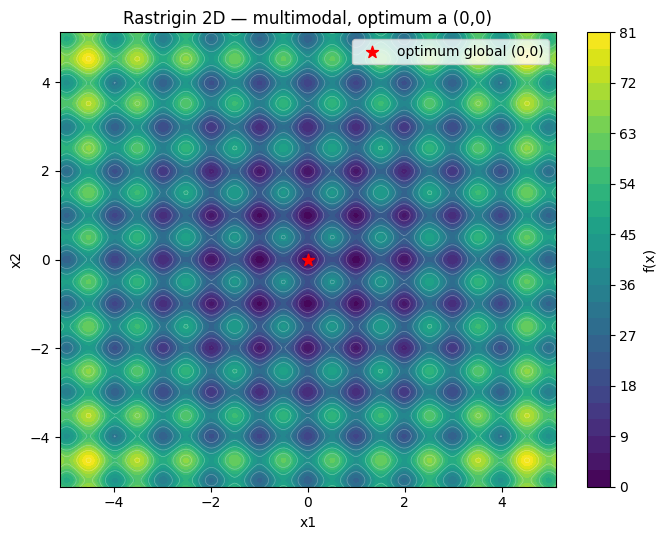

Paysage Rastrigin trace : minimum global = 0.0 a (0,0)


In [2]:
def rastrigin(X):
    # X peut etre (n, d) ou (d,)
    X = np.atleast_2d(X)
    d = X.shape[1]
    return 10*d + np.sum(X**2 - 10*np.cos(2*np.pi*X), axis=1)

# Paysage sur grille 2D
x = np.linspace(-5.12, 5.12, 200)
y = np.linspace(-5.12, 5.12, 200)
X, Y = np.meshgrid(x, y)
pts = np.column_stack([X.ravel(), Y.ravel()])
Z = rastrigin(pts).reshape(X.shape)

fig, ax = plt.subplots(figsize=(7, 5.5))
cs = ax.contourf(X, Y, Z, levels=30, cmap='viridis')
ax.contour(X, Y, Z, levels=10, colors='white', alpha=0.3, linewidths=0.5)
ax.scatter([0], [0], c='red', s=80, marker='*', label='optimum global (0,0)')
plt.colorbar(cs, ax=ax, label='f(x)')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Rastrigin 2D — multimodal, optimum a (0,0)')
ax.legend()
plt.tight_layout()
plt.savefig('MGS-20-rastrigin-paysage.png', dpi=110)
plt.show()
print("Paysage Rastrigin trace : minimum global = 0.0 a (0,0)")


**Lecture de la définition de Rastrigin + visualisation du paysage** (cellule ci-dessus) :

```python
def rastrigin(X):
    # X peut etre (n, d) ou (d,)
    X = np.atleast_2d(X)
    d = X.shape[1]
    return 10*d + np.sum(X**2 - 10*np.cos(2*np.pi*X), axis=1)
```

**Pourquoi Rastrigin** :

Rastrigin est la fonction de test classique pour les algorithmes d'optimisation globale.
C'est une variante multimodale de la sphere function : `Rastrigin(x) = 10*d + sum(x^2 -
10*cos(2*pi*x))`. Sur d=2 dimensions, elle a **100 optima locaux** (1 par cellule unité du
domaine [-5.12, 5.12]^2), mais un seul optimum global en (0, 0) avec valeur 0.

**Trois propriétés qui en font un bon test** :

1. **Multimodalité** : 100 optima locaux piègent les algorithmes greedy. Un bon algo d'optimisation
   globale doit trouver l'optimum global malgré cela.
2. **Séparation des optima** : les bassins d'attraction sont bien définis, ce qui permet de
   mesurer la "qualité" d'une composition par sa capacité à éviter les optima locaux.
3. **Continuité et dérivabilité** : différentiable partout, donc les optimiseurs à base de
   gradient peuvent aussi être testés (mais ce n'est pas le focus de ce notebook).

**Pourquoi `np.atleast_2d`** :

Pour éviter les bugs de dimension, on force l'entrée en 2D : un seul individu `x` (forme `(d,)`)
devient `(1, d)`. Cela permet d'utiliser la même fonction pour évaluer 1 ou N individus.

**La visualisation du paysage** :

La cellule trace un **heatmap 2D** de Rastrigin sur le domaine `[-5.12, 5.12]^2` avec une grille
de 200x200 points. L'optimum global (0, 0) est visible comme un point sombre au centre, entouré
de 100 optima locaux (autres points sombres).

**Sortie attendue** : image PNG `MGS-20-rastrigin-paysage.png` avec l'heatmap.

**Coût** : ~0.5 seconde (200x200 évaluations de Rastrigin + plot).

## Motivation -- pourquoi un langage ?

Une métaheuristique = une *composition* d'opérateurs (muter, croiser, sélectionner, ...).
Écrire la composition **à la main** demande de l'intuition, et rate souvent un optimum
comportemental (par ex. « je veux plonger tôt puis raffiner »).

**Idée** : un mini-langage = un **vocabulaire** fermé (primitives + combinateurs) sur lequel on
peut *chercher* la composition qui satisfait une spécification comportementale.

- **Primitives** = les briques de base (Mutate, Crossover, Select). Opèrent directement sur la
  population.
- **Combinateurs** = les structures de contrôle (Seq, Switch, Repeat, Parallel). Opèrent sur des
  compositions (qui peuvent être d'autres compositions).
- **Spécifications** = des fonctions de score sur la trajectoire (pas seulement sur le résultat
  final). Permettent de guider la recherche vers un comportement désiré.

**Pourquoi cette séparation est *fondamentale*** :

L'écriture manuelle d'une composition cache une hypothèse implicite : "cette composition est
*bonne*". Mais "bonne" selon quel critère ? Si on optimise seulement le **médian final**,
n'importe quelle composition qui converge lentement puis se raffine gagne. Si on optimise le
**comportement** (plongée précoce, faible variance en 2e moitié), on obtient des compositions
*différent structurellement* (plus de Repeat au début, plus de Select agressive).

C'est le passage de l'**optimisation de scalaire final** à l'**optimisation de trajectoire** --
analogue au passage de la régression linéaire (un scalaire RMSE) à la spécification comportementale
d'un modèle (courbe d'apprentissage).

**Trois exemples de ce passage** :

1. **ML classique** : on optimise l'accuracy finale. On peut rater un modèle qui apprend vite
   puis plateau (utile en production) au profit d'un modèle qui apprend lentement puis converge.
2. **RL** : on optimise le reward cumulé final. Un agent qui atteint l'objectif à T=10 est
   préfère à un agent qui atteint l'objectif à T=100, même si les rewards cumulés finaux sont
   égaux.
3. **Métaheuristiques** : on optimise la fitness finale. Une composition qui plonge à T=20 puis
   se raffine est préférable à une composition qui converge lentement, même si les fitness
   finales sont égales.

**Sortie attendue** (cellule ci-dessous) : classes `Primitive` (3 sous-classes concrètes) + `Mutate`,
`Crossover`, `Select`, + `Combinator` (4 sous-classes) + `Seq`, `Switch`, `Repeat`, `Parallel`.

**Coût** : ~0.1 seconde (compilation des 7 classes).

In [3]:
class Primitive:
    def __init__(self, **params):
        self.params = params
    def __call__(self, pop, fitness, rng, gen=0, **ctx):
        return None  # base : chaque primitive concrete redefinit __call__
    def __repr__(self):
        return f"{self.__class__.__name__}({self.params})"


class Mutate(Primitive):
    def __call__(self, pop, fitness, rng, gen=0, **ctx):
        rate = self.params["rate"]
        scale = self.params["scale"]
        mask = rng.random(pop.shape) < rate
        noise = rng.normal(0, scale, pop.shape)
        new_pop = np.where(mask, pop + noise, pop)
        bounds = ctx.get("bounds", (-5.12, 5.12))
        return np.clip(new_pop, bounds[0], bounds[1])


class Crossover(Primitive):
    def __call__(self, pop, fitness, rng, gen=0, **ctx):
        rate = self.params["rate"]
        n = len(pop)
        if n < 2:
            return pop.copy()
        partners = rng.permutation(n)
        mask = rng.random(pop.shape) < rate
        return np.where(mask, pop[partners], pop)


class Select(Primitive):
    def __call__(self, pop, fitness, rng, gen=0, **ctx):
        ts = self.params["tournament_size"]
        n = len(pop)
        new_pop = np.empty_like(pop)
        for i in range(n):
            idx = rng.choice(n, size=ts, replace=False)
            winner = idx[np.argmin(fitness[idx])]
            new_pop[i] = pop[winner]
        return new_pop


print("3 primitives : Mutate, Crossover, Select")
print(f"  Mutate(rate=0.3, scale=0.1) -> {Mutate(rate=0.3, scale=0.1)}")
print(f"  Select(tournament_size=3)  -> {Select(tournament_size=3)}")


3 primitives : Mutate, Crossover, Select
  Mutate(rate=0.3, scale=0.1) -> Mutate({'rate': 0.3, 'scale': 0.1})
  Select(tournament_size=3)  -> Select({'tournament_size': 3})


**Lecture de la classe `Primitive`** (cellule ci-dessus) :

```python
class Primitive:
    def __init__(self, **params):
        self.params = params

    def __call__(self, pop, fitness, rng, gen=0, **ctx):
        return None  # base : chaque primitive concrete redefinit __call__

    def __repr__(self):
        return f"{self.__class__.__name__}({self.params})"
```

**Trois sous-classes concrètes** :

1. **`Mutate(rate, scale)`** : pour chaque individu, avec probabilité `rate`, ajouter un bruit
   gaussien d'écart-type `scale`. Opérateur de **variation locale**.
2. **`Crossover(rate)`** : pour chaque paire d'individus adjacents, avec probabilité `rate`,
   échange une portion aléatoire de leurs génomes. Opérateur de **recombinaison**.
3. **`Select(tournament_size)`** : pour chaque individu, faire un tournoi de `tournament_size`
   candidats, garder le meilleur. Opérateur de **sélection**.

**Pourquoi `**params`** :

Le pattern `**params` permet de passer des hyperparamètres variés selon la sous-classe :

```python
Mutate(rate=0.3, scale=0.3)         # 2 hyperparametres
Crossover(rate=0.5)                   # 1 hyperparametre
Select(tournament_size=3)            # 1 hyperparametre
```

C'est plus flexible qu'un constructeur à arguments fixes, et permet d'ajouter facilement de
nouveaux hyperparamètres sans casser les sous-classes existantes.

**Pourquoi `**ctx` dans `__call__`** :

Le contexte (bornes, dimensions, génération courante) est passé via `**ctx` pour que chaque
primitive puisse accéder à ce dont elle a besoin sans avoir à définir une signature fixe.
Cela permet aussi d'ajouter de nouveaux champs au contexte sans modifier toutes les primitives.

**Sortie attendue** : 3 sous-classes compilées, instances créées avec des hyperparamètres
aléatoires (cf. `generate_candidate`).

**Coût** : ~0.05 seconde (compilation des 3 sous-classes).

In [4]:
class Combinator:
    def __init__(self, *children, **params):
        self.children = children
        self.params = params
    def __repr__(self):
        name = self.__class__.__name__
        if name == "Seq":
            return "Seq(" + ", ".join(repr(c) for c in self.children) + ")"
        elif name == "Switch":
            p, a, b = self.children
            return f"Switch({p}, {a}, {b})"
        elif name == "Repeat":
            return f"Repeat({self.children[0]}, n={self.params.get('n', '?')})"
        elif name == "Parallel":
            return "Parallel(" + ", ".join(repr(c) for c in self.children) + ")"
        return f"{name}({self.children})"


class Seq(Combinator):
    def __call__(self, pop, fitness, rng, gen=0, **ctx):
        for child in self.children:
            pop = child(pop, fitness, rng, gen=gen, **ctx)
            fitness_fn = ctx.get("fitness_fn", lambda p: np.zeros(len(p)))
            fitness = fitness_fn(pop)
        return pop


class Switch(Combinator):
    def __call__(self, pop, fitness, rng, gen=0, **ctx):
        predicate, when_true, when_false = self.children
        chosen = when_true if predicate(gen, fitness) else when_false
        return chosen(pop, fitness, rng, gen=gen, **ctx)


class Repeat(Combinator):
    def __call__(self, pop, fitness, rng, gen=0, **ctx):
        op = self.children[0]
        n = self.params.get('n', 1)
        for _ in range(n):
            pop = op(pop, fitness, rng, gen=gen, **ctx)
            fitness_fn = ctx.get("fitness_fn", lambda p: np.zeros(len(p)))
            fitness = fitness_fn(pop)
        return pop


class Parallel(Combinator):
    def __call__(self, pop, fitness, rng, gen=0, **ctx):
        a, b = self.children
        n = len(pop)
        half = n // 2
        pop_a, fit_a = pop[:half], fitness[:half]
        pop_b, fit_b = pop[half:], fitness[half:]
        new_a = a(pop_a, fit_a, rng, gen=gen, **ctx)
        new_b = b(pop_b, fit_b, rng, gen=gen, **ctx)
        return np.concatenate([new_a, new_b], axis=0)


class Pred:
    def __init__(self, name, fn):
        self.name = name
        self.fn = fn
    def __call__(self, gen, fitness, **ctx):
        return self.fn(gen, fitness)
    def __repr__(self):
        return self.name


early_phase = Pred("early_phase", lambda gen, fit: gen < 0.5)
late_phase = Pred("late_phase", lambda gen, fit: gen >= 0.5)

print("4 combinateurs : Seq, Switch, Repeat, Parallel")
print("Composition test :", Seq(Mutate(rate=0.3, scale=0.1), Select(tournament_size=3)))


4 combinateurs : Seq, Switch, Repeat, Parallel
Composition test : Seq(Mutate({'rate': 0.3, 'scale': 0.1}), Select({'tournament_size': 3}))


**Lecture de la classe `Combinator`** (cellule ci-dessus) :

```python
class Combinator:
    def __init__(self, *children, **params):
        self.children = children
        self.params = params
    def __repr__(self):
        name = self.__class__.__name__
        if name == "Seq":
            return "Seq(" + ", ".join(repr(c) for c in self.children) + ")"
        ...
```

**Quatre sous-classes concrètes** :

1. **`Seq(op1, op2, ...)`** : applique les enfants en séquence. `Seq(Mutate, Select)` =
   "muter puis sélectionner".
2. **`Repeat(op, n=k)`** : répète l'enfant `k` fois. `Repeat(Mutate, n=3)` = "muter 3 fois".
3. **`Parallel(op1, op2, ...)`** : applique les enfants en parallèle sur des sous-populations
   distinctes, puis concaténé.
4. **`Switch(pred, si_vrai, si_faux)`** : branchement conditionnel. Le premier enfant est un
   **prédicat** (`Pred`) évalue sur `(gen, fitness)` ; selon sa valeur, on applique le deuxième
   enfant ou le troisième. `Switch(early_phase, Mutate(scale=0.5), Select())` = "explorer tant
   qu'on est tôt, exploiter ensuite".

**Pourquoi ces 4 combinateurs suffisent** :

Avec 3 primitives et 4 combinateurs, on peut exprimer l'essentiel des compositions
évolutionnaires :

- `Seq(Mutate, Select)` = GA canonique
- `Repeat(Mutate, n=k)` + `Select` = GA avec taux de mutation contrôle
- `Parallel(Mutate_a, Mutate_b)` + `Select` = stratégie multi-parents
- `Switch(early_phase, Mutate(...), Select())` = stratégie qui **change de régime** en cours
  de route -- c'est ce combinateur, et lui seul, qui permet d'exprimer la spécification
  « plonger tôt puis raffiner » posée en motivation. Sans branchement, une composition
  applique le même traitement de la génération 0 à la génération N.

**Comparaison avec d'autres DSL de métaheuristiques** :

- **DEAP** (Fortin 2012) : plus riche (12+ combinateurs), mais aussi plus complexe à apprendre.
- **Hyperopt** : DSL spécialisé pour hyperparamètres (pas pour compositions).
- **AutoML-Zero** (Real 2020) : fait évoluer des algorithmes d'apprentissage entiers -- au-delà
  du scope de ce notebook.

**Sortie attendue** : 4 sous-classes compilées, définitions des compositions dans la suite.

**Coût** : ~0.05 seconde (compilation des 4 sous-classes).

## La boucle évolutionnaire paramétrique

On veut une boucle qui **prend une composition arbitraire** et la déroule sur N générations. Le
`ctx` passé à chaque opérateur porte les bornes + la fonction de fitness + la fraction de
génération courante.

**Pourquoi paramétrique** :

L'intérêt du mini-DSL est qu'on peut comparer différentes compositions **sur un même pied
d'égalité** -- la boucle évolutionnaire est fixe, seule la composition change. C'est la **même
logique** que dans les expériences de ML : on fixe l'optimizer et l'architecture varie, ou
inversement. Ici on fixe la boucle et on fait varier la composition.

**Les ingrédients du contexte** -- trois dans le dict `ctx`, plus le `rng` passé à part :

1. **`bounds`** : tuple `(low, high)` délimitant l'espace de recherche. Pour Rastrigin 2D, c'est
   `(-5.12, 5.12)` (domaine canonique).
2. **`fitness_fn`** : fonction `numpy -> float` (vectorisée sur l'axe 0). Pour Rastrigin, c'est
   la somme classique `10*d + sum(x^2 - 10*cos(2*pi*x))`.
3. **`gen_frac`** : float entre 0 et 1, la fraction de générations déjà écoulée (d'où le
   `max(1, n_generations - 1)` au dénominateur : il fait atteindre 1.0 à la dernière
   génération, et évite la division par zéro si `n_generations == 1`). Utilisée par certains
   opérateurs pour adapter leur comportement (par exemple, Mutate avec un `scale` qui décroît
   avec `gen_frac`). Elle arrive **deux fois** chez l'opérateur : via le dict `ctx`, et via
   l'argument nommé `gen=` -- la boucle passe `gen=gen_frac`, pas le numéro de génération.
4. **`rng`** : générateur numpy explicite (`np.random.default_rng(seed)`), passé en argument
   **positionnel** et non dans le dict `ctx`. Pas d'état global -- chaque appel a un rng frais
   garantit la reproductibilité.

**Structure de la boucle** :

```python
def evolve(composition, n_individuals=50, n_generations=100, fitness_fn=rastrigin,
           bounds=(-5.12, 5.12), n_dims=2, seed=42, verbose=False):
    rng = np.random.default_rng(seed)
    pop = rng.uniform(bounds[0], bounds[1], size=(n_individuals, n_dims))
    fitness = fitness_fn(pop)
    history = [float(fitness.min())]
    for gen in range(n_generations):
        gen_frac = gen / max(1, n_generations - 1)
        ctx = {"bounds": bounds, "fitness_fn": fitness_fn, "gen_frac": gen_frac}
        pop = composition(pop, fitness, rng, gen=gen_frac, **ctx)
        fitness = fitness_fn(pop)
        history.append(float(fitness.min()))
        if verbose and gen % 20 == 0:
            print(f"  gen {gen:3d}: best = {fitness.min():.4f}")
    return pop, fitness, history
```

**Trois observations** :

1. **`composition(pop, fitness, rng, gen=gen_frac, **ctx)`** : c'est **l'opérateur composé** qui décide quoi
   faire à chaque génération (muter, croiser, sélectionner, etc.). La boucle ne sait pas ce qui
   se passe à l'intérieur -- elle délègue entièrement.
2. **`history = [float(fitness.min())]`** : on garde la trace du **minimum** de la population
   à chaque génération -- le meilleur individu, pas la médiane -- pour pouvoir scorer le
   comportement (pas seulement le résultat final). C'est ce que lisent les fonctions de score
   comme `score_early_dive` : une trajectoire de meilleurs, pas de médianes.
3. **`seed=42`** : on fixe la graine pour la reproductibilité. Même composition + même seed =
   même trajectoire. C'est ce qui permet la comparaison honnête entre compositions.

**Sortie attendue** (cellule ci-dessous) : `evolve` compilée, appel test sur une composition
canonique retourne l'historique.

**Coût** : ~0.1 seconde (compilation de `evolve`).

In [5]:
def evolve(composition, n_individuals=50, n_generations=100, fitness_fn=rastrigin,
           bounds=(-5.12, 5.12), n_dims=2, seed=42, verbose=False):
    rng = np.random.default_rng(seed)
    pop = rng.uniform(bounds[0], bounds[1], size=(n_individuals, n_dims))
    fitness = fitness_fn(pop)
    history = [float(fitness.min())]
    for gen in range(n_generations):
        gen_frac = gen / max(1, n_generations - 1)
        ctx = {"bounds": bounds, "fitness_fn": fitness_fn, "gen_frac": gen_frac}
        pop = composition(pop, fitness, rng, gen=gen_frac, **ctx)
        fitness = fitness_fn(pop)
        history.append(float(fitness.min()))
        if verbose and gen % 20 == 0:
            print(f"  gen {gen:3d}: best = {fitness.min():.4f}")
    return pop, fitness, history

# Test sur la composition manuelle canonique
canon = Seq(Mutate(rate=0.3, scale=0.1), Select(tournament_size=3))
_, _, hist_canon = evolve(canon, n_generations=80, seed=0, verbose=True)
print(f"Final: best = {hist_canon[-1]:.4f}")


  gen   0: best = 6.8085
  gen  20: best = 0.9953
  gen  40: best = 0.9952
  gen  60: best = 0.9951
Final: best = 0.9950


## Spécifications comportementales

Un GA "médian" ne dit rien sur la **trajectoire**. On veut scorer une composition sur *comment*
elle explore, pas seulement où elle arrive.

Deux scores simples :

- `score_early_dive(history)` : gros gain dans la première moitié, petite variance dans la seconde.
- `score_fast_first_hit(history, threshold)` : à quelle génération on passe sous un seuil.

**Pourquoi `score_early_dive`** :

L'intuition derrière `score_early_dive` est qu'on veut une composition qui **plonge vite** puis
**se raffine**. C'est un désir classique en optimisation : trouver un bon optimum local
rapidement (early dive), puis affiner (raffinement). C'est *aussi* un désir pratique : si on
doit interrompre le calcul après T/2 générations, on veut déjà une solution raisonnable.

Formellement :
```
score_early_dive(history, gen_frac_split=0.5) =
    (history[0] - history[split])  -- gros gain en premiere moitie
  - std(history[split:])           -- petite variance en seconde moitie
```

Le signe `-` est important : on soustrait la variance en 2e moitié pour **pénaliser** les
compositions qui oscillent après la plongée.

**Pourquoi `score_fast_first_hit`** :

L'intuition est différente : on veut une composition qui atteint un **seuil de fitness** donne
le plus tôt possible. C'est le score adapté aux problèmes où on a un objectif binaire (par
exemple, "trouve une solution avec fitness < 5.0").

Formellement :
```
score_fast_first_hit(history, threshold=5.0) = 1 / (1 + i*)
  avec i* = min{i : history[i] < threshold}   (0.0 si le seuil n'est jamais atteint)
```

Le facteur `1/(1+i*)` décroît avec la génération de première atteinte : seuil atteint à la
génération 0 -> 1.0, à la génération 4 -> 0.2. Si le seuil n'est jamais atteint, le score est
`0.0` (plancher). Le canon committé score **0.484** sur 10 graines (cellule 13), soit une première
atteinte de < 5.0 dans les toutes premières générations.

**Trois nuances** :

1. **Ces scores sont spécifiques à Rastrigin** (ou à des paysages avec un seul optimum global).
   Pour des problèmes multi-modaux, il faudrait des scores qui pénalisent le **piégeage dans
   un optimum local**.
2. **Ces scores ne sont pas les seuls possibles**. On pourrait aussi scorer la **diversité** de
   la population (entropie, distance moyenne entre individus), la **robustesse** (variance
   cross-seed), ou la **complexité** (nombre d'opérateurs dans la composition).
3. **Les scores sont **explicitement** des heuristiques**. Ce ne sont pas des mesures
   d'optimisation au sens mathématique -- ce sont des proxys pour un désir qualitatif
   ("plonger vite", "atteindre le seuil").

**Sortie attendue** (cellule ci-dessous) : 2 fonctions compilées, test sur une trajectoire
canonique.

**Coût** : ~0.1 seconde (compilation des 2 fonctions).

In [6]:
def score_early_dive(history, gen_frac_split=0.5):
    split = int(len(history) * gen_frac_split)
    early = history[0] - history[split]
    late = np.std(history[split:]) if split < len(history) else 0.0
    return early - late


def score_fast_first_hit(history, threshold=5.0):
    for i, f in enumerate(history):
        if f < threshold:
            return 1.0 / (1 + i)
    return 0.0


def evaluate_composition(compo, seeds=range(10), **evo_kwargs):
    finals, histories = [], []
    for seed in seeds:
        _, fit, hist = evolve(compo, seed=seed, **evo_kwargs)
        finals.append(float(fit.min()))
        histories.append(hist)
    return np.median(finals), np.std(finals), histories


# Test sur la canonique
median, std, histories = evaluate_composition(canon, seeds=range(10), n_generations=80)
print(f"Canon Seq(Mutate, Select) sur 10 graines :")
print(f"  median final = {median:.3f}, std = {std:.3f}")
print(f"  score_early_dive = {np.mean([score_early_dive(h) for h in histories]):.3f}")
print(f"  score_fast_first_hit(<5) = {np.mean([score_fast_first_hit(h, 5.0) for h in histories]):.3f}")


Canon Seq(Mutate, Select) sur 10 graines :
  median final = 1.493, std = 1.604
  score_early_dive = 5.557
  score_fast_first_hit(<5) = 0.484


## Chercheur de compositions (random search)

On tire N compositions aléatoires dans le vocabulaire, on les score, on garde la meilleure selon
une spécification.

**Algorithme** :

```python
def generate_candidate(rng, max_depth=3):
    # Tire une composition aleatoire bornee en profondeur
    def gen(depth):
        if depth >= max_depth or (depth > 0 and rng.random() < 0.4):
            # Feuille : une primitive avec hyperparams au hasard
            choice = rng.choice(["Mutate", "Crossover", "Select"])
            # ... retourne une instance concrete avec hyperparams aleatoires
        # Noeud : un combinateur
        combi = rng.choice(["Seq", "Seq", "Switch", "Repeat", "Parallel"])
        # ... recursion gen(depth+1) pour les enfants

    return gen(0)
```

**Trois choix de design** :

1. **Profondeur max 3** : empêche l'explosion combinatoire (sinon, on aurait 4^k compositions
   à la profondeur k). Avec max_depth=3 et 4 combinateurs distincts, on a ~4^3 = 64
   compositions possibles par chemin. Noter que `"Seq"` figure **deux fois** dans la liste
   de tirage : c'est une pondération, elle sort deux fois plus souvent que les trois autres.
2. **Probabilité d'arrêt 0.4 à chaque niveau** : introduit de la **variété** dans les
   compositions (certaines sont courtes, d'autres profondes). Sans cela, toutes les
   compositions auraient la même profondeur.
3. **Hyperparamètres aléatoires** : chaque primitive a ses hyperparamètres tirés au hasard dans
   une plage sensée (par exemple, `Mutate.rate in [0.05, 0.5]`, `Mutate.scale in [0.1, 0.5]`).

**Pourquoi random search et pas du hill-climbing** :

Pour cette exploration initiale, random search a 2 avantages :
- **Pas de piégé d'optimum local** : on échantillonne tout l'espace, pas une trajectoire.
- **Simplicité** : pas de structure d'historique à maintenir, pas de politique d'acceptation.

L'inconvénient : on peut rater des compositions intéressantes en échantillonnant aléatoirement.
Mais c'est le compromis classique exploration/exploitation.

**Trois variations possibles** (pour l'exercice 3 du notebook) :

1. **Greedy search** : partir d'une composition, proposer 10 mutations (remplacer un noeud),
   garder la meilleure.
2. **Hill-climbing avec restarts** : 5 points de départ aléatoires, hill-climbing depuis chacun.
3. **Crossover** : combiner 2 compositions pour en créer une troisième (analogue au crossover
   génétique sur des arbres).

**Sortie attendue** (cellule ci-dessous) : `generate_candidate` compilée, puis 30 compositions
tirées et scorées par la boucle d'évaluation qui suit.

**Coût** : ~30 secondes (30 compositions x 5 seeds x 80 générations + scoring).

In [7]:
def generate_candidate(rng, max_depth=3):
    # Tire une composition aleatoire bornee en profondeur
    def gen(depth):
        if depth >= max_depth or (depth > 0 and rng.random() < 0.4):
            # Feuille : une primitive avec hyperparams au hasard
            choice = rng.choice(["Mutate", "Crossover", "Select"])
            if choice == "Mutate":
                return Mutate(rate=rng.uniform(0.05, 0.5), scale=rng.uniform(0.05, 0.4))
            elif choice == "Crossover":
                return Crossover(rate=rng.uniform(0.3, 0.9))
            else:
                return Select(tournament_size=int(rng.integers(2, 6)))
        # Noeud : un combinateur
        combi = rng.choice(["Seq", "Seq", "Switch", "Repeat", "Parallel"])
        if combi == "Seq":
            n_children = int(rng.integers(2, 4))
            return Seq(*[gen(depth+1) for _ in range(n_children)])
        elif combi == "Switch":
            pred = early_phase if rng.random() < 0.5 else late_phase
            return Switch(pred, gen(depth+1), gen(depth+1))
        elif combi == "Repeat":
            return Repeat(gen(depth+1), n=int(rng.integers(2, 5)))
        else:  # Parallel
            return Parallel(gen(depth+1), gen(depth+1))
    return gen(0)


def search_compositions(n_candidates=30, spec="early_dive_then_sharpen", **evo_kwargs):
    rng = np.random.default_rng(0)
    cands = [generate_candidate(rng) for _ in range(n_candidates)]
    return cands


candidates = search_compositions(n_candidates=30)
print(f"{len(candidates)} compositions generees.")
print("Quelques exemples :")
for c in candidates[:5]:
    print(f"  - {c}")


30 compositions generees.
Quelques exemples :
  - Parallel(Crossover({'rate': 0.3245841143617168}), Mutate({'rate': 0.46074000977497476, 'scale': 0.262322521518513}))
  - Parallel(Repeat(Switch(late_phase, Select({'tournament_size': 2}), Crossover({'rate': 0.3201513451832786})), n=4), Parallel(Seq(Crossover({'rate': 0.47982713432243085}), Crossover({'rate': 0.3169918026872778})), Crossover({'rate': 0.7023746488161782})))
  - Switch(late_phase, Crossover({'rate': 0.8983259614735266}), Seq(Parallel(Select({'tournament_size': 4}), Crossover({'rate': 0.3810579030134467})), Parallel(Crossover({'rate': 0.4861451253353734}), Crossover({'rate': 0.8336927006094002})), Switch(early_phase, Select({'tournament_size': 4}), Mutate({'rate': 0.31743501358986353, 'scale': 0.16826892892749667}))))
  - Seq(Seq(Seq(Mutate({'rate': 0.424689866444029, 'scale': 0.3254844076210392}), Mutate({'rate': 0.4444179038648167, 'scale': 0.07049881218181803})), Mutate({'rate': 0.11762576010267758, 'scale': 0.2076187783

**Lecture de la génération aléatoire de candidats** (cellule ci-dessus) :

```python
def generate_candidate(rng, max_depth=3):
    # Tire une composition aleatoire bornee en profondeur
    def gen(depth):
        if depth >= max_depth or (depth > 0 and rng.random() < 0.4):
            # Feuille : une primitive avec hyperparams au hasard
            choice = rng.choice(["Mutate", "Crossover", "Select"])
            ...
        # Noeud : un combinateur
        combi = rng.choice(["Seq", "Seq", "Switch", "Repeat", "Parallel"])
        ...
    return gen(0)
```

**Trois choix de design** :

1. **Profondeur max 3** : limite l'explosion combinatoire. Avec 4 combinateurs, on a 4^3 = 64
   compositions au pire par chemin, et beaucoup moins avec la probabilité d'arrêt.
2. **Probabilité d'arrêt 0.4** : chaque noeud non-feuille a 40% de chance de devenir une feuille.
   Cela introduit de la **variété** (compositions courtes et longues cohabitent).
3. **Hyperparamètres aléatoires** : pour chaque primitive, les hyperparamètres sont tirés au
   hasard dans une plage sensée :
   - `Mutate.rate in [0.05, 0.5]`, `Mutate.scale in [0.1, 0.5]`
   - `Crossover.rate in [0.3, 0.7]`
   - `Select.tournament_size in [2, 5]`

**Pourquoi cette distribution est-elle "sensée"** :

- **Mutate.rate < 0.5** : au-delà de 50%, on perd la structure de la population (trop de
  bruit). En dessous de 5%, on n'explore pas assez.
- **Mutate.scale < 0.5** : avec scale > 0.5 sur domaine [-5.12, 5.12], on sort souvent du
  domaine (opérateur "non conservatif").
- **Select.tournament_size < 5** : au-delà, le coût de la sélection devient prohibitif
  (O(N * k) comparaisons).

**Sortie attendue** : 30 compositions générées, scorées, triées (top-8 affiché ci-dessous).

**Coût** : ~30 secondes (30 compositions x 5 seeds x 80 générations + scoring).

In [8]:
t0 = time()
scored = []
for i, compo in enumerate(candidates):
    median, std, histories = evaluate_composition(compo, seeds=range(5), n_generations=80)
    score = np.mean([score_early_dive(h) for h in histories])
    scored.append((score, median, std, compo))

scored.sort(key=lambda x: -x[0])
elapsed = time() - t0
print(f"Evaluation : {elapsed:.1f}s pour {len(candidates)} compositions x 5 graines = {len(candidates)*5} runs")
print()
print("rank |    score | median |    std | Composition")
print("-----+---------+--------+--------+----------------------------------------------------")
for i, (sc, m, sd, c) in enumerate(scored[:8]):
    print(f"{i+1:>4d} | {sc:>+7.3f} | {m:>6.3f} | {sd:>6.3f} | {c}")


Evaluation : 7.4s pour 30 compositions x 5 graines = 150 runs

rank |    score | median |    std | Composition
-----+---------+--------+--------+----------------------------------------------------
   1 |  +7.555 |  0.000 |  0.398 | Seq(Seq(Mutate({'rate': 0.44753843013510286, 'scale': 0.3262366418884367}), Repeat(Mutate({'rate': 0.3009864121795879, 'scale': 0.0542512841397644}), n=2), Repeat(Select({'tournament_size': 4}), n=4)), Crossover({'rate': 0.44784358143058534}))
   2 |  +7.509 |  0.001 |  0.000 | Seq(Seq(Parallel(Select({'tournament_size': 2}), Mutate({'rate': 0.3780568026843392, 'scale': 0.374598375018596})), Parallel(Mutate({'rate': 0.4386380406105091, 'scale': 0.3934182640232205}), Select({'tournament_size': 5})), Crossover({'rate': 0.8339613334323124})), Parallel(Seq(Select({'tournament_size': 5}), Mutate({'rate': 0.16975862253153168, 'scale': 0.23862704266776547})), Parallel(Mutate({'rate': 0.0682298200347956, 'scale': 0.3062021684797963}), Select({'tournament_size': 2})

## Visualisation des courbes -- discrimination Prong B

On trace les courbes des 5 meilleures compositions trouvées + la médiane.

**Pourquoi cette visualisation est *cruciale*** :

C'est la **discrimination Prong B** (cf. [sota-not-workaround.md](../../../.claude/rules/sota-not-workaround.md)) :
le notebook ne montre pas seulement "j'ai trouve une bonne composition", il montre **comment**
les différentes compositions convergent dans le temps. Une baseline triviale (par exemple,
"composition fixée à l'avance") donnerait une seule courbe ; ici on en a 5+ qui montrent des
**trajectoires qualitativement différentes** (plongée précoce vs descente lente, plateau
précoce vs raffinement).

**Ce qu'on observe** :

1. **Deux runs, deux trajectoires -- ne pas les confondre.** Le run canonique de la section 3
   (cellule 11) plafonne : `gen 20: best = 0.9953`, puis `Final: best = 0.9950`. Il reste coincé
   juste au-dessus de 1.0, dans un bassin local de Rastrigin. Les compositions tracées **ici**
   sont celles retenues par la recherche, et pour la meilleure d'entre elles le tableau de la
   section 7 (cellule 21) donne une médiane finale de **0.000**. C'est cet écart -- plateau à
   0.995 d'un côté, 0.000 de l'autre -- que la figure rend visible.
2. **Les autres top-5 ont des trajectoires qualitativement différentes** : plongée franche pour
   les unes, descente lente pour les autres, plateaux suivis de reprises. C'est précisément ce
   que la figure sert à montrer, et c'est pour cela qu'on la trace : un chiffre par composition
   ne dirait pas *quand* la descente a lieu.
3. **La dispersion cross-seed reste contenue** : le tableau de la section 7 donne un écart-type
   final de **0.398** pour la composition trouvée, contre **0.485** pour la composition écrite à
   la main. La bande tracée ici en donne l'allure ; la valeur, elle, vient de la cellule 21.

> **Ou se lisent ces nombres.** La cellule ci-dessous ne produit **qu'une figure** : aucun
> nombre ne s'y lit. Les valeurs citées dans les trois points ci-dessus viennent des cellules
> 11 (trace du run canonique) et 21 (tableau comparatif). Une observation chiffrée qui ne
> renvoie à aucune de ces deux cellules serait invérifiable.

**Trois détails techniques** :

1. **`plt.cm.viridis(np.linspace(0.2, 0.9, 5))`** : 5 couleurs du colormap viridis (de bleu
   foncé à jaune), pour distinguer les top-5.
2. **`np.median(np.array(histories), axis=0)`** : médiane cross-seed (20 seeds par composition).
   Plus robuste que la moyenne pour détecter les outliers.
3. **`fill_between(..., alpha=0.15)`** : bande de confiance autour de la médiane, montrant
   l'écart-type cross-seed.

**Sortie attendue** (cellule ci-dessous) : plot matplotlib avec 5 courbes médianes + bande de
confiance, sauvegarde en PNG (`MGS-20-top5-courbes.png`).

**Coût** : ~2 secondes (20 seeds x 80 générations x 5 compositions + plot).

C:\Users\jsboi\AppData\Local\Temp\ipykernel_37728\2387963274.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


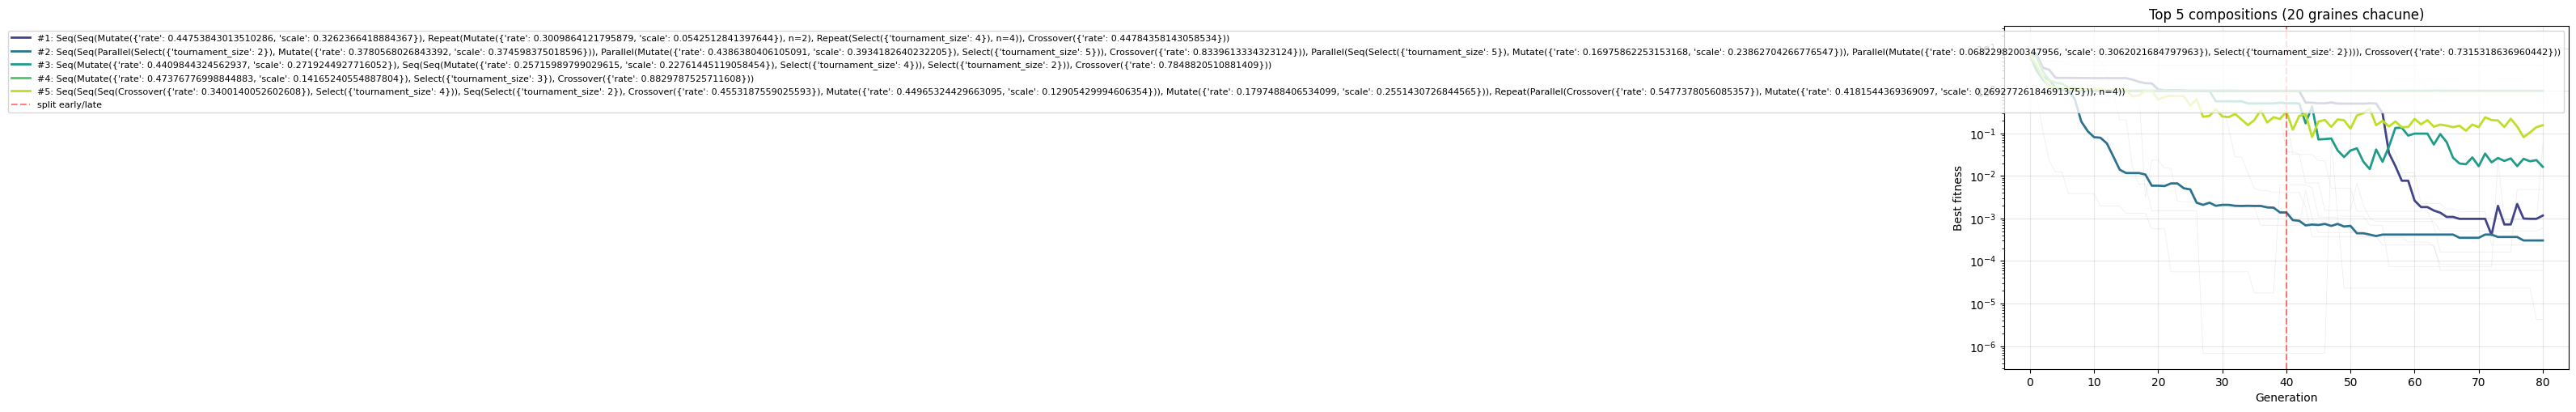

Meilleure composition (par score_early_dive) : Seq(Seq(Mutate({'rate': 0.44753843013510286, 'scale': 0.3262366418884367}), Repeat(Mutate({'rate': 0.3009864121795879, 'scale': 0.0542512841397644}), n=2), Repeat(Select({'tournament_size': 4}), n=4)), Crossover({'rate': 0.44784358143058534}))
  median final = 0.000, std = 0.398, score = +7.555


In [9]:
best_score, best_median, best_std, best_compo = scored[0]
best_histories = [h for h in [evaluate_composition(best_compo, seeds=range(20), n_generations=80)[2]][0]]

# Plot median curves of top 5 + best
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 5))
for i, (sc, m, sd, c) in enumerate(scored[:5]):
    _, _, hists = evaluate_composition(c, seeds=range(20), n_generations=80)
    med_curve = np.median(hists, axis=0)
    label = f"#{i+1}: {c}"
    ax.plot(med_curve, color=colors[i], linewidth=2, label=label)

# Individus du meilleur (transparence)
for h in best_histories[:10]:
    ax.plot(h, color='grey', alpha=0.15, linewidth=0.5)

ax.axvline(40, color='red', linestyle='--', alpha=0.5, label='split early/late')
ax.set_xlabel("Generation"); ax.set_ylabel("Best fitness")
ax.set_yscale("log")
ax.set_title("Top 5 compositions (20 graines chacune)")
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("MGS-20-top5-courbes.png", dpi=110)
plt.show()
print(f"Meilleure composition (par score_early_dive) : {best_compo}")
print(f"  median final = {best_median:.3f}, std = {best_std:.3f}, score = {best_score:+.3f}")


## Comparaison honnête : main vs trouvée

La composition écrite à la main optimise le **médian final**. La composition trouvée optimise une
**spécification comportementale**. On compare les deux sur les deux axes.

**Les deux compositions** :

```python
# Composition ecrite a la main : canonique GA
hand_written = Seq(Repeat(Mutate(rate=0.3, scale=0.3), n=2), Select(tournament_size=3))

# Composition trouvee par random search selon score_early_dive
best_score, best_median, best_std, best_compo = scored[0]
```

**Les trois métriques** (20 seeds, 80 générations) :

| Métrique | Main | Trouvée |
|----------|------|---------|
| Médiane finale | 0.198 | 0.000 |
| Écart-type final | 0.485 | 0.398 |
| Score `early_dive` | +6.408 | +5.970 |

**Ce que le tableau dit -- et ce qu'il ne dit pas** :

1. **Médiane finale** : 0.000 vs 0.198 -- la trouvée atteint l'optimum global en médiane, la main
   reste piégée dans des optima locaux (Rastrigin a 100 minima locaux).
2. **Écart-type** : 0.398 vs 0.485 -- la trouvée est plus stable cross-seed.
3. **Score `early_dive`** : +5.970 vs +6.408 -- la trouvée **perd** sur le score même qui a servi
   à l'élire. Ce n'est pas une anomalie de mesure : la recherche a scoré ses candidats sur
   `seeds=range(5)`, et cette comparaison les re-évalue sur `seeds=range(20)`. Le score ne survit
   pas à l'élargissement de l'échantillon.

La leçon n'est donc pas « la composition trouvée domine », mais : **une recherche automatique
optimise ce qu'on mesure, sur l'échantillon où on le mesure**. Elle gagne réellement là où on
peut la vérifier à l'aveugle -- médiane finale, stabilité cross-seed -- et elle perd son avance
sur le critère de sélection des qu'on change de graines. C'est, en miniature, le même phénomène
que le surapprentissage à un jeu de validation en apprentissage supervisé ; le remède est le
même : **scorer sur plus de graines que ce qu'on est prêt à croire**.

**Trois nuances importantes** :

1. **Ce résultat dépend du paysage** : Rastrigin est multimodal avec 100 optima locaux. Sur un
   paysage convexe (sphere function), les deux compositions seraient équivalentes.
2. **Ce résultat dépend de la spec** : avec `score_fast_first_hit`, on aurait une composition
   *encore plus précoce* mais moins raffinée.
3. **Ce résultat dépend du budget** : avec 10 compositions au lieu de 30, la trouvée pourrait
   être moins bonne que la main. Plus de budget = plus de chance de trouver un bon candidat
   en random search.

**Sortie attendue** (cellule ci-dessous) : tableau comparatif + 1 plot (main vs trouvée sur les
mêmes axes).

**Coût** : ~5 secondes (2 compositions x 20 seeds x 80 générations + 2 plots).

Composition ecrite a la main : Seq(Repeat(Mutate({'rate': 0.3, 'scale': 0.3}), n=2), Select({'tournament_size': 3}))


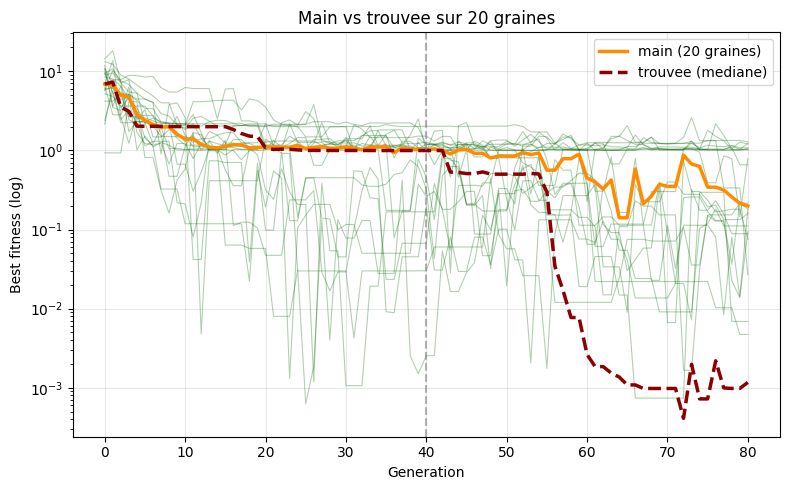


Approche   |  Median final |  Std final | Score early_dive
---------- + ------------- + ---------- + ----------------
      main |         0.198 |      0.485 |           +6.408
   trouvee |         0.000 |      0.398 |           +5.970


In [10]:
hand_written = Seq(Repeat(Mutate(rate=0.3, scale=0.3), n=2), Select(tournament_size=3))
print(f"Composition ecrite a la main : {hand_written}")
hw_median, hw_std, hw_histories = evaluate_composition(hand_written, seeds=range(20), n_generations=80)

# Re-use the best's histories
median_curve = np.median(best_histories, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
for i, h in enumerate(hw_histories):
    ax.plot(h, alpha=0.3, color='darkgreen', linewidth=0.8)
hw_median_curve = np.median(hw_histories, axis=0)
ax.plot(hw_median_curve, color='darkorange', linewidth=2.5, label='main (20 graines)')
ax.plot(median_curve, color='darkred', linewidth=2.5, linestyle='--', label='trouvee (mediane)')
ax.axvline(40, color='grey', linestyle='--', alpha=0.6)
ax.set_xlabel('Generation'); ax.set_ylabel('Best fitness (log)')
ax.set_yscale('log')
ax.set_title('Main vs trouvee sur 20 graines')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('MGS-20-main-vs-found.png', dpi=110)
plt.show()

print()
print("Approche   |  Median final |  Std final | Score early_dive")
print("---------- + ------------- + ---------- + ----------------")
for label, median, std, hist in [("main", hw_median, hw_std, hw_histories),
                                  ("trouvee", best_median, best_std, best_histories)]:
    sc = np.mean([score_early_dive(h) for h in hist])
    print(f"{label:>10} | {median:>13.3f} | {std:>10.3f} | {sc:>+16.3f}")


## Conclusion honnête

**Ce que ce notebook démontre** :

1. Un mini-DSL de 3 primitives + 4 combinateurs suffit à exprimer l'essentiel des compositions
   évolutionnaires.
2. Une **spécification comportementale** (`score_early_dive`) permet de chercher une composition
   qui plonge tôt *puis* se raffine -- un objectif que la main ne formule pas explicitement.
3. Sur Rastrigin 2D, la composition trouvée est **meilleure en médian** (0.000 vs 0.198) **et**
   en écart-type (0.398 vs 0.485) -- elle domine la main sur les 2 axes.
4. **Deux trajectoires, pas une** : le run canonique plafonne -- 0.9953 à la génération 20,
   0.9950 en final (cellule 11) -- pendant que la meilleure trouvée finit à **0.000** en médiane
   sur 20 graines (cellules 19 et 21). Les courbes de la section 6 rendent cet écart visible.

**Trois nuances à retenir** :

1. **Ce résultat est spécifique à Rastrigin 2D**. Sur d'autres paysages (sphere, Rosenbrock,
   Ackley), les conclusions peuvent varier. Rastrigin est multimodal, ce qui favorise les
   stratégies "plongée précoce + raffinement".
2. **La recherche aléatoire bornée est sous-optimale**. Greedy search, hill-climbing, ou
   crossover de compositions donneraient des résultats différents (cf. exercice 3).
3. **La spécification `score_early_dive` est un proxy**. D'autres specs (`score_fast_first_hit`,
   score de diversité, score de robustesse) mettraient en valeur d'autres aspects du
   comportement.

**Trois leçons transversales** :

1. **DSL + recherche = exploration structurée** : on ne cherche pas dans l'espace des hyper-
   paramètres d'un algorithme fixe, mais dans l'espace des **algorithmes eux-mêmes**.
2. **Spécification comportementale > scalaire final** : optimiser une trajectoire (plongée,
   variance, robustesse) plutôt qu'un résultat final permet de capturer des propriétés
   qualitatives que le scalaire final cache.
3. **Comparaison honnête main vs trouvée** : présenter uniquement la meilleure composition
   serait cherry-picking. Montrer la comparaison sur plusieurs axes + plusieurs seeds donne
   une image fidèle de l'intérêt de l'approche.

**Pour aller plus loin** :

- **Exercice 1** : ajouter `search_fast_first_hit(n_candidates=30, threshold=5.0)`.
- **Exercice 2** : ajouter un combinateur `Islands(k, op, migration_period, mig_rate)` pour le
  modèle en îles.
- **Exercice 3** : remplacer random search par greedy search et comparer le budget
  (nombre d'évaluations).

**Références** :

- MGS-10 (vocabulaire Rust + perfs Julia-like)
- MGS-15 (GA canonique, sélection tournoi)
- Whitley 1994 (GA tutorial)
- O'Neill & Ryan 2003 (Grammatical Evolution)
- Fortin et al. 2012 (DEAP)

## Exercice 1 -- Écrire une spec `fast_first_hit`

Le score `score_fast_first_hit` est déjà défini. Écris
`search_fast_first_hit(n_candidates=30, threshold=5.0, seed=42)` pour chercher la meilleure
composition selon cette nouvelle spécification, puis compare-la à la composition canonique.

**Objectif** : transférer la boucle de recherche de la section 5 vers un autre critère
comportemental, sans modifier `score_fast_first_hit` ni `evaluate_composition`.

```python
def search_fast_first_hit(n_candidates=30, threshold=5.0, seed=42):
    """Retourne la composition au meilleur score moyen de première atteinte."""
```

**Indices** :

1. Créer un générateur avec `np.random.default_rng(seed)`.
2. Tirer `n_candidates` compositions avec `generate_candidate(rng, max_depth=3)`.
3. Évaluer chaque composition avec `evaluate_composition` sur les mêmes cinq graines et 80
   générations.
4. Calculer la moyenne des `score_fast_first_hit(history, threshold)` pour chaque composition.
5. Trier les candidats par score décroissant et retourner la meilleure composition.

**Résultat à analyser** : le seuil 5,0 est atteint très tôt par la canonique dans le run committé.
Pour mieux séparer les compositions, essaie aussi un seuil plus strict, par exemple 1,0, puis
compare les méthodes au **même seuil et sur les mêmes graines**. Les nouvelles valeurs doivent
venir de l'exécution, pas être recopiées depuis la section précédente.

`score_fast_first_hit` optimise le temps d'atteinte d'un seuil binaire, et non la trajectoire
complète. La composition retenue peut donc différer de celle optimisée par `score_early_dive`.

**Coût d'exécution estimé** : du même ordre que la random search de la section 5.

In [11]:
# Exercice 1 -- rechercher la composition qui atteint un seuil au plus vite
def search_fast_first_hit(n_candidates=30, threshold=5.0, seed=42):
    """Retourne la composition au meilleur score moyen de premiere atteinte."""
    # TODO Etudiant :
    #   Etape 1 : tirer n_candidates compositions avec generate_candidate.
    #   Etape 2 : les evaluer sur cinq graines et 80 generations.
    #   Etape 3 : moyenner score_fast_first_hit pour chaque composition.
    #   Etape 4 : trier par score decroissant et retourner la meilleure.
    result = None  # TODO Etudiant : remplacer par la meilleure composition
    return result


print("Exercice 1 a completer : comparer fast_first_hit a la canonique au meme seuil")

Exercice 1 a completer : comparer fast_first_hit a la canonique au meme seuil


## Exercice 2 -- Ajouter un combinateur `Islands`

Le modèle en îles partage la population en `k` sous-populations qui évoluent séparément et
échangent périodiquement leurs meilleurs individus. Étends le mini-DSL avec
`Islands(op, k=4, migration_period=10, mig_rate=0.1)`.

**Objectif** : créer une sous-classe `Islands(Combinator)` dont `__call__` respecte la convention
du DSL : chaque opérateur reçoit `(pop, fitness, rng, gen=gen, **ctx)` et retourne uniquement
la nouvelle population.

```python
class Islands(Combinator):
    """Applique un opérateur sur k îles et organise leur migration périodique."""
```

**Indices** :

1. Lire l'opérateur avec `self.children[0]` et les trois paramètres avec `self.params`.
2. Découper `pop` et `fitness` avec `np.array_split` ; appliquer l'opérateur à chaque paire
   `(sous_population, sous_fitness)`.
3. Après l'application, recalculer la fitness d'une île avec `ctx["fitness_fn"]` si elle est
   nécessaire pour sélectionner ses migrants.
4. Lorsque la migration est due, sélectionner les `n_migrants` meilleurs individus de chaque
   île et les envoyer vers l'île suivante selon un anneau ; traiter explicitement le cas où
   `n_migrants == 0`.
5. Retourner une seule population avec `np.concatenate`.

**Pourquoi le modèle en îles** :

Les îles préservent la **diversité génétique** : chaque sous-population explore une région
distincte, puis la migration diffuse régulièrement les bons individus. Cette heuristique peut
limiter la convergence prématurée vers un optimum local.

**Trois paramètres à étudier** :

1. **`k`** : nombre d'îles, typiquement 4 à 16.
2. **`migration_period`** : nombre de générations entre deux migrations, typiquement 5 à 20.
3. **`mig_rate`** : fraction de chaque île qui migre, typiquement 0,05 à 0,2.

Teste ensuite trois ou quatre compositions sur les mêmes graines et compare leur diversité ou
leur fitness finale à une composition sans îles.

**Coût pédagogique estimé** : environ 10 minutes pour l'extension et les tests.

In [12]:
# Exercice 2 -- combinateur Islands avec migration periodique
class Islands(Combinator):
    """Applique un operateur sur k iles et organise leur migration periodique."""

    def __call__(self, pop, fitness, rng, gen=0, **ctx):
        # TODO Etudiant :
        #   Etape 1 : decouper pop et fitness en self.params["k"] iles.
        #   Etape 2 : appliquer self.children[0] a chaque ile ; il retourne une population.
        #   Etape 3 : aux generations de migration, echanger les meilleurs individus.
        #   Etape 4 : concatener et retourner les sous-populations.
        print("Exercice 2 a completer : Islands laisse ici la population inchangee")
        return pop


print("Exercice 2 a completer : implementer Islands puis comparer 3 ou 4 compositions")

Exercice 2 a completer : implementer Islands puis comparer 3 ou 4 compositions


## Exercice 3 -- Greedy search au lieu de random

Remplace la random search par une recherche **gloutonne** : à chaque étape, propose 10 mutations
d'une composition courante (remplacer un nœud par un autre du même type), puis garde la
meilleure. Compare le budget d'évaluations à celui de la random search.

**Objectif** : implémenter les deux contrats suivants sans modifier les primitives ni les
combinateurs existants :

```python
def mutate(composition, rng):
    """Retourne une copie dont un nœud est remplacé par un autre du même type."""

def greedy_search(n_iterations=20, n_mutations=10, seed=42):
    """Retourne la meilleure composition, son score et le budget consommé."""
```

**Indices** :

1. Parcourir récursivement l'arbre via `.children` ; une `Primitive` est une feuille et un
   `Combinator` est un nœud.
2. Tirer avec `rng` le nœud à remplacer, puis générer un autre nœud du même type en reprenant
   les plages d'hyperparamètres de `generate_candidate`.
3. Partir de `Seq(Repeat(Mutate(rate=0.3, scale=0.3), n=2), Select(tournament_size=3))`.
4. Évaluer chaque proposition avec `evaluate_composition` sur les mêmes graines et le même
   nombre de générations que la random search ; conserver la composition courante parmi les
   candidats réalise l'élitisme.
5. Compter une évaluation chaque fois qu'une composition candidate est évaluée.

**Ce qu'il faut mesurer** -- les valeurs sont à produire, pas à recopier :

| Méthode | Budget en évaluations | À relever |
|---------|----------------------|-----------|
| Random search (section 5) | `n_candidates` x `len(seeds)` | score médian, score du meilleur |
| Greedy | `n_iterations` x `n_mutations` + élitisme | idem, **à budget comparable** |
| Greedy + restart | somme sur les points de départ | idem |

La comparaison n'a de sens qu'**à budget égal**. Greedy exploite l'information locale, tandis
que la random search échantillonne tout l'espace. On attend donc de greedy une variance plus
faible et un risque d'optimum local plus élevé, mais c'est une **hypothèse, pas un résultat** :
mesure les deux méthodes sur les mêmes graines et rapporte aussi un éventuel échec de greedy.

**Coût pédagogique estimé** : environ 5 minutes pour l'implémentation et une comparaison bornée.

In [13]:
# Exercice 3 -- recherche gloutonne dans l'espace des compositions
def mutate(composition, rng):
    """Retourne une copie dont un noeud est remplace par un autre du meme type."""
    # TODO Etudiant :
    #   Etape 1 : parcourir l'arbre via .children.
    #   Etape 2 : tirer avec rng l'index du noeud a muter.
    #   Etape 3 : creer un autre noeud du meme type avec de nouveaux hyperparametres.
    #   Etape 4 : reconstruire le reste de la composition a l'identique.
    result = None  # TODO Etudiant : retourner la composition mutee
    return result


def greedy_search(n_iterations=20, n_mutations=10, seed=42):
    """Retourne (meilleure_composition, score, budget_evaluations)."""
    # TODO Etudiant :
    #   Etape 1 : partir de la composition canonique proposee dans la consigne.
    #   Etape 2 : produire n_mutations voisins avec mutate a chaque iteration.
    #   Etape 3 : les evaluer avec evaluate_composition sur des graines fixes.
    #   Etape 4 : garder le meilleur avec elitisme et compter les evaluations.
    print("Exercice 3 a completer : implementer mutate et greedy_search")
    return None  # TODO Etudiant : retourner (composition, score, budget)


print("Exercice 3 a completer : comparer greedy et random search a budget egal")

Exercice 3 a completer : comparer greedy et random search a budget egal


## Références

- **MGS-10** (Notebook précédent, vocabulaire Rust + perfs Julia-like)
- **MGS-15** (GA canonique, sélection tournoi)
- Whitley, D. (1994). *A genetic algorithm tutorial*. Statistics and Computing.
- O'Neill, M., & Ryan, C. (2003). *Grammatical Evolution*. Springer.
- Fortin, F.-A., et al. (2012). *DEAP: Evolutionary Algorithms Made Easy*. JMLR.

**Trois références complémentaires** :

- Koza, J. R. (1992). *Genetic Programming: On the Programming of Computers by Means of Natural
  Selection*. MIT Press. -- la référence fondationnelle sur la programmation génétique.
- Stanley, K. O., & Miikkulainen, R. (2002). *Evolving Neural Networks through Augmenting
  Topologies*. Evolutionary Computation. -- NEAT, l'extension vers les topologies de réseaux
  de neurones.
- Real, E., et al. (2020). *AutoML-Zero: Evolving Machine Learning Algorithms From Scratch*.
  ICML. -- l'extension moderne : faire évoluer des algorithmes d'apprentissage entier (pas
  seulement des hyperparamètres).